# prep workspace

In [1]:
#Import relevant packages
import numpy as np
import pandas as pd
from matplotlib import rcParams
import os
from pathlib import Path
import scanpy as sc

import matplotlib as mpl
import matplotlib.pyplot as plt

#For nice color schemes
import cmocean

#For barplots
import seaborn as sns

import matplotlib as mpl
import matplotlib.pyplot as plt

In [2]:
#Import scVI
import scvi
from scvi.model.utils import mde

scvi.settings.verbosity = 40

In [3]:
#Set fontsize
plt.rcParams.update({'font.size': 20})

In [4]:
#Set path to directory containing data 
DATADIR = Path('~/oliverlab/data/ONB/').expanduser()
if not DATADIR.exists():
    DATADIR = Path('/Volumes/Hackathon1/DukeSeq/ONB')

In [5]:
#Show specific size of pandas dataframe when produced
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

In [6]:
%matplotlib inline

In [10]:
adata = sc.read_h5ad(Path(DATADIR,'RPM_RPMA_GBC_Allografts/adata_RPM_RPMA_Allo_Primary_Clustered_Final_021724.h5ad'))

In [11]:
adata

AnnData object with n_obs × n_vars = 26812 × 56173
    obs: 'genotype', 'mouse_ident', 'n_genes_by_counts', 'total_counts', 'total_counts_mito', 'pct_counts_mito', 'tumor_type', 'log1p_total_counts', 'leiden_scVI_1.1', 'leiden_scVI_1.2', 'leiden_scVI_1.3', 'leiden_scVI_1.4', 'leiden_scVI_1.5', 'leiden_scVI_1.6', 'leiden_scVI_tumor_1.1', 'batch', 'S_score', 'G2M_score', 'phase', 'leiden_scVI_all_allograft_1.1', 'leiden_scVI_all_allograft_1.1_10k_hvg', 'leiden', 'dpt_pseudotime', 'dpt_groups', 'dpt_order', 'dpt_order_indices', 'leiden_underscore', 'broad_cluster_names', 'broad_cluster_names_non_neuronal_split'
    var: 'feature_types-0', 'gene_ids-0', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'highly_variable_rank-0', 'means-0', 'variances-0', 'variances_norm-0', 'highly_variable_nbatches-0', 'mean_-0', 'frac_zero-0', 'feature_types-1', 'gene_ids-1', 'feature_types-2', 'gene_ids-2', 'mito', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_cou

As before for integration of other atlases, removed low quality cell clusters based on gene expression patterns, average counts, and average mitochondrial DNA. Each time a cluster was removed, the model was re-trained, starting from highly variable gene selection. In the case of the RPM and RPMA allografts, it only took two iterations to remove low quality clusters.

# full atlas plots

KeyError: 'Could not find key cluster_names in .var_names or .obs.columns.'

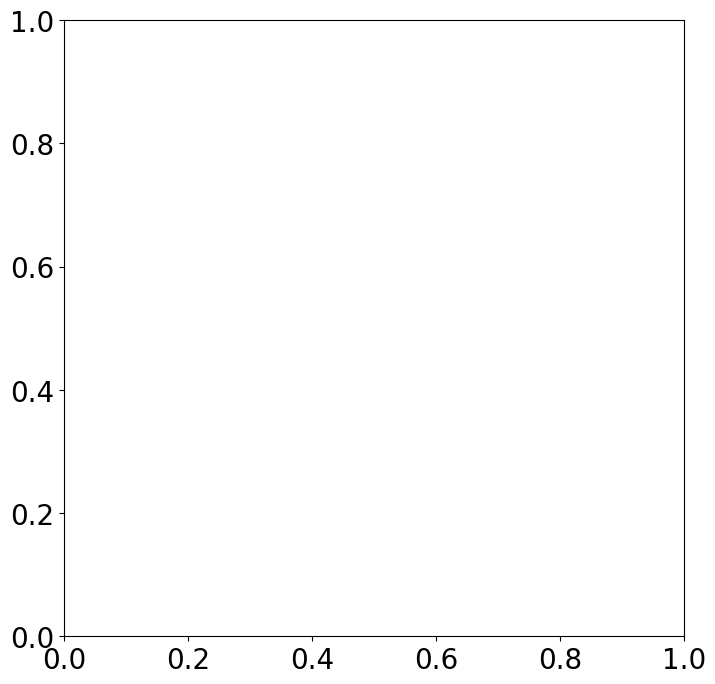

In [ ]:
# to plot UMAP coloring only primary and allograft tumor clusters

palette=[ 'lightgray', #(BG)
        'lightgray', #(Fibroblast)
       'lightgray', #(GBC)
         'lightgray', #(HBC)
        'lightgray', #(INP)
         'lightgray', #(Lymphoid)
       'lightgray', #(MV ionocyte)
         'lightgray', #(MV tuft)
        'lightgray', #(Myeloid)
         'lightgray', #(OEC)
        'lightgray', #(Pericyte)
         '#984ea3', #(RPM tumor)
         '#ff7f0e', #RPMA tumor
         'turquoise', #RPMA allograft
         'tab:blue', #RPM allograft
       'lightgray', #sus
      'lightgray', #iOSN
     'lightgray' #mOSN
        ]



### NOTE
The plot below currently fails due to the absence of `adata.obs['cluster_names']`

In [ ]:
# fig, ax = plt.subplots(figsize=(8, 8))
# sc.pl.umap(adata, color="cluster_names", legend_loc="right margin", ax=ax, s=4, frameon=False, save=False, palette=palette)

For optimal transport, same code was followed as that presented earlier in notebook 5, sub-section "Optimal transport"

# scvi tumors only

In [13]:
adata = sc.read_h5ad(Path(DATADIR,'Global_Atlas_wRPM_RPMA_ONB/RPM_RPMA_tumor_cells_only.h5ad'))

In [16]:
adata

AnnData object with n_obs × n_vars = 3463 × 56160
    obs: 'genotype', 'mouse_ident', 'n_genes_by_counts', 'total_counts', 'total_counts_mito', 'pct_counts_mito', 'tumor_type', 'log1p_total_counts', 'leiden_scVI_1.1', 'leiden_scVI_1.2', 'leiden_scVI_1.3', 'leiden_scVI_1.4', 'leiden_scVI_1.5', 'leiden_scVI_1.6', 'leiden_scVI_tumor_1.1'
    var: 'feature_types', 'gene_ids', 'mito', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean_', 'frac_zero'
    uns: 'genotype_colors', 'hvg', 'leiden', 'leiden_scVI_1.1_colors', 'leiden_scVI_1.2_colors', 'leiden_scVI_1.3_colors', 'leiden_scVI_1.4_colors', 'leiden_scVI_1.5_colors', 'leiden_scVI_1.6_colors', 'leiden_scVI_tumor_1.1_colors', 'mouse_ident_colors', 'neighbors', 'rank_genes_groups', 'umap'
    obsm: 'X_scVI_1.1', 'X_scVI_1.2', 'X_scVI_1.3', 'X_scVI_1.4', 'X_scVI_1.5', 'X_scVI_1.6', 'X_scVI_tumor_1.1'

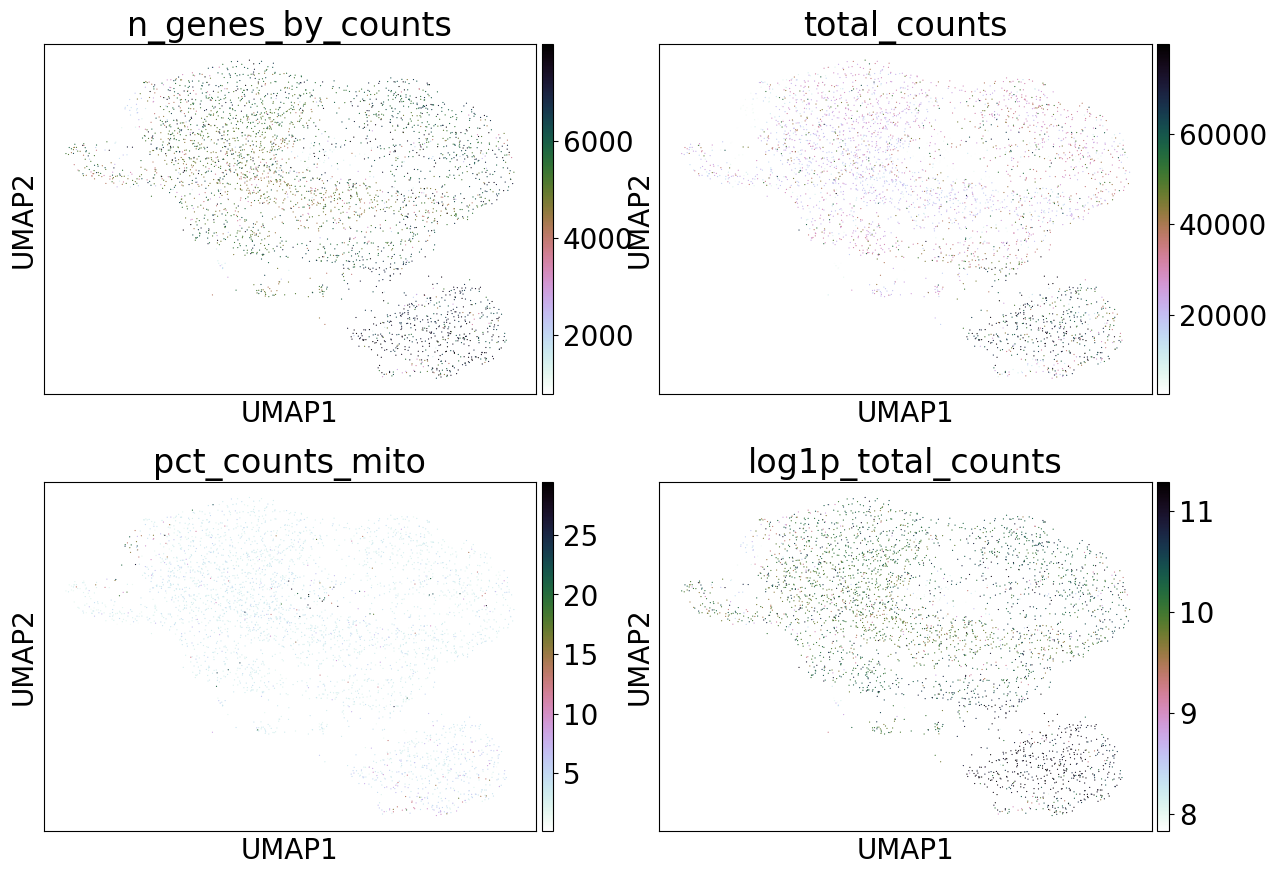

In [14]:
#QC UMAPs
sc.pl.umap(
    adata,
    color=["n_genes_by_counts", "total_counts", "pct_counts_mito", "log1p_total_counts"],
    cmap="cubehelix_r",
    s=3,
    ncols=2,
)

# PAGA and diffusion pseudotime

In [ ]:
# Start with tumor adata object generated from above section (with new scvi tumor specific embeddings)
# sc.pp.neighbors(adata, n_neighbors=35, use_rep='X_scVI_all_allograft_1.1')
sc.tl.umap(adata)
sc.tl.draw_graph(adata)

In [ ]:
sc.pl.draw_graph(adata, color='leiden_scVI_all_allograft_1.1', legend_loc='right margin')

In [ ]:
# run paga
sc.tl.leiden(adata, resolution=1.2)
sc.tl.paga(adata, groups='leiden')
sc.pl.paga(adata, threshold=0.03, show=False)
sc.tl.draw_graph(adata, init_pos='paga')
sc.pl.draw_graph(adata, color=['leiden', 'mouse_ident',
                              'leiden_scVI_all_allograft_1.1'], legend_loc='right margin')

In [ ]:
# check gene expression across plot 
# this also generates feature plots for the FA plots used in the paper figures
genes = ['Tubb3', 'Neurod1',
         'Lhx2', 'Sox11',
         'Foxi1', 'Cftr',
         'Vim', 'Pou2f3', 'Trpm5', 
         'Chat', 'Avil', 'Pou2f3',
         'Sox2', 'Cyp2j6', 'Cxcl17',
         'Sox9', 'Sox10', 'Runx1',
         'Runx1t1', 'Krt8',  'Krt18',
         'Krt5', 'Trp63',
         'Ezh2', 'Kit', 'Myc',
        'Hes6', 'Mki67', 'Top2a',
        'Epcam', 'Ncam1', 'Ascl1',
        'Krt5', 'Foxj1',
        'Cfap126', 'fLuc', 'CellTag.UTR',
         'GFP.CDS']


sc.pl.draw_graph(adata, color=genes, legend_loc='right margin', vmax='p99.5',
                 color_map='cmo.dense', ncols=3, frameon=False, layer='norm'
                    )

In [ ]:
# set root for pseudotime
adata.uns['iroot'] = np.flatnonzero(adata.obs['leiden']  == '7')[0]

In [ ]:
# compute
sc.tl.diffmap(adata, n_comps=30)
sc.tl.dpt(adata, n_branchings=5)

In [ ]:
# plot pseudotime
with plt.rc_context({'figure.figsize': (6, 5)}):
    sc.pl.draw_graph(adata, color=['dpt_pseudotime'], legend_loc='right margin', s=10, frameon=False, save=False,
                    vmax=0.5
                    )

In [ ]:
# Find cluster markers for each leiden cluster
sc.tl.rank_genes_groups(adata, 'leiden_scVI_all_allograft_1.1', method='wilcoxon', layer='norm', use_raw=False)
pd.DataFrame(adata.uns['rank_genes_groups']['names']).head(30)

Next, generate pseudotime heatmap plot

In [ ]:
# specify paths for each branch
paths = [('Neuronal', [7, 10, 3, 12]),
         ('MV2-like', [7, 8]),
        ('MV1/glandular-like', [7, 11, 13, 1, 9]),
        ('Mesenchymal', [7, 11, 13, 2]),
        ('Stem-like', [7, 11, 0, 5, 6])]

In [ ]:
adata.obs['distance'] = adata.obs['dpt_pseudotime']

In [ ]:
# set .X to the normalized layer (for plotting purposes below)
adata.X = adata.layers['norm']

# and log the data for plotting purposes 
sc.pp.log1p(adata)

# finally scale between 0 and 1 
adata.X = csr_matrix(np.clip(adata.X.toarray(), 0, 1))

In [ ]:
# import
from scipy.sparse import csr_matrix

In [ ]:
# specify gene names for the heatmap
gene_names =['Ascl1', 'Kit',
             'Neurod1', 'Lhx2', 'Tubb3','Runx1t1', 
             'Foxi1', 'Runx1', 'Cftr', 
             'Krt8', 'Krt18', 
            'Sox9', 'Sox10',
             'Vim', 'Cd44', 
            'Sox2', 'Mecom']

In [ ]:
#Plot
_, axs = plt.subplots(ncols=5, figsize=(24, 9), gridspec_kw={'wspace': 0.05, 'left': 0.12})
plt.subplots_adjust(left=0.05, right=0.98, top=0.82, bottom=0.2)
for ipath, (descr, path) in enumerate(paths):
    _, data = sc.pl.paga_path(
        adata, path, gene_names,
        show_node_names=False,
        ax=axs[ipath],
        ytick_fontsize=12,
        left_margin=0.15,
        n_avg=200,
        annotations=['distance'],
        show_yticks=True if ipath==0 else False,
        show_colorbar=True,
        color_map='Purples',
        groups_key='leiden_scVI_all_allograft_1.1',
        color_maps_annotations={'distance': 'cmo.haline'},
        title='{} path'.format(descr),
        return_data=True,
        normalize_to_zero_one=False,
        show=False, xlim=[0,0.8])
    

plt.savefig('Pseudotime_celltag_paths_RPM_and_RPMA_allografts.pdf')  
plt.show()

# Celltag plots

Prior to running this section, please run the celltag clone calling described in the R script (8_celltag_clone_calling_analysis). 

In [ ]:
# start with same adata object (primary and allograft tumors only) generated above
adata = sc.read_h5ad('ONB_primary_allografts_only_scvi.h5ad')

In [ ]:
# read in celltag clone info df
df_ct = pd.read_csv('RPM_RPMA_celltag_clones.csv')

In [ ]:
# Set index to barcode so it matches adata.obs
df_ct.index=df_ct['Cell barcodes']

In [ ]:
adata.obs = pd.merge(adata.obs, df_ct[['CellTag_Clone', 'Cell barcodes']], left_index=True, right_index=True, how='left')

In [ ]:
# check clone counts
adata.obs.CellTag_Clone.value_counts()

In [ ]:
# create FA plot with clone cells plotted on top

# import
from matplotlib import gridspec


# select clone
clone='RPMA_clone_42'


fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])
 
# Plot the UMAP on the left
ax0 = plt.subplot(gs[0])
condition_h2023_6 = adata.obs['CellTag_Clone'] == clone
 
# Scatter plot for 'Other' cells
scatter2 = ax0.scatter(
    adata.obsm['X_draw_graph_fa'][~condition_h2023_6, 0],
    adata.obsm['X_draw_graph_fa'][~condition_h2023_6, 1],
    s=2,
    c='lightgray',
    label='Other'
)
 
# Scatter plot for clone cells
scatter1 = ax0.scatter(
    adata.obsm['X_draw_graph_fa'][condition_h2023_6, 0],
    adata.obsm['X_draw_graph_fa'][condition_h2023_6, 1],
    s=10,
    c='tab:blue',
    label=clone
)

ax0.set_title(clone)
ax0.axis('off')

# Adjust the layout
plt.tight_layout()
plt.show()

In [ ]:
# next plot background cells (FA plot)
with plt.rc_context({'figure.figsize': (4, 4)}):
    sc.pl.draw_graph(adata, color=['mouse_ident'], frameon=False,
                     legend_loc='right margin', s=50, save=True, palette=['lavender', #RPMA allograft
                                                                                               'lavender', #RPM allograft
                                                                                               'lavender', #RPM tumor
                                                                                               'lavender', # RPMA 1
                                                                                           'lavender',  # RPMA 2
                                                                                           'lavender']) #RPMA 3

In [ ]:
# Now going through process of selecting cells only from given clone, to generate connectivity FA plot

# Select rows where 'CellTag_Clone' is 'specified clone' and get the corresponding indices
indices_clone = df_ct[df_ct['CellTag_Clone'] == 'RPMA_clone_42'].index.tolist()

# filter adata to just selected clone
adata_clone = adata[indices_clone, :]

del adata_clone.uns['iroot']
sc.pp.neighbors(adata_clone, n_neighbors=35, use_rep='X_scVI_all_allograft_1.1')
sc.tl.paga(adata_clone, groups='broad_cluster_names')

In [ ]:
# plot connectivities graph
with plt.rc_context({'figure.figsize': (9, 6)}):
    sc.pl.paga_compare(
    adata_clone, threshold=0.5, title='', right_margin=0.2, edge_width_scale=0.5,
    legend_fontsize=12, fontsize=12, frameon=False, edges=True, save=True, legend_loc='',
    color='broad_cluster_names', size=1500
    )